In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../src/utils/')
sys.path.append('../../src/benchmark/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small, xcit_medium
from train_functions import train_epochs
from utils import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid
from RotateConvolution import RotateConv2d

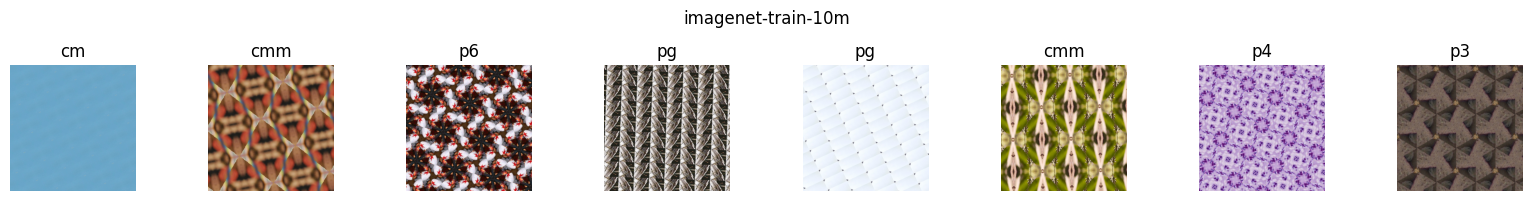

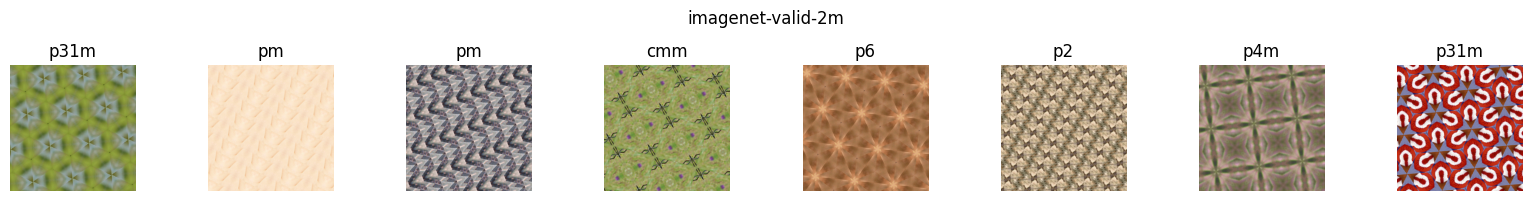

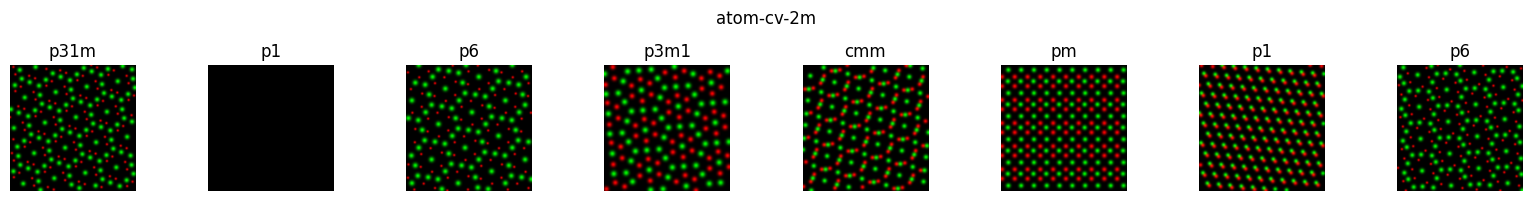

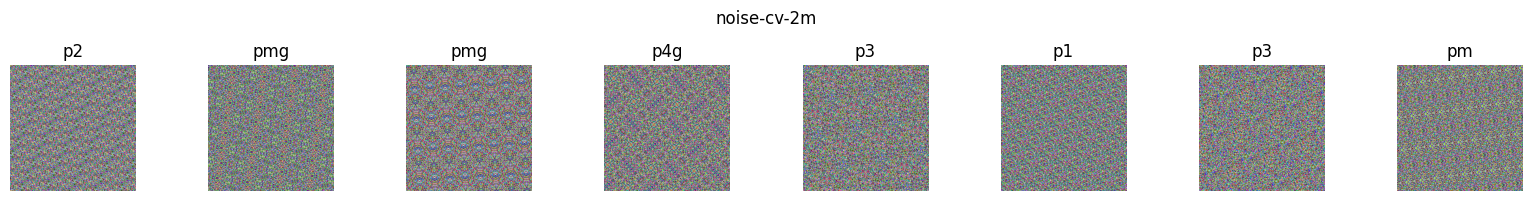

In [2]:
# with h5py.File('/mnt/raid0/yichen/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', 'r') as h5:
#     viz_h5_structure(h5)
num_workers = 8
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('/mnt/raid0/yichen/imagenet_v4_rot_10m_train_unchunked.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=3000, shuffle=True, num_workers=num_workers)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet-train-10m')

valid_dl = DataLoader(valid_ds, batch_size=3000, shuffle=True, num_workers=num_workers)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet-valid-2m')

# atom-cv-2m
cv_atom_ds_2m = hdf5_dataset('/mnt/raid0/yichen/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
cv_atom_dl_2m = DataLoader(cv_atom_ds_2m, batch_size=3000, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_atom_dl_2m, label_converter=label_converter, title='atom-cv-2m')

# noise-cv-2m
cv_noise_ds_2m = hdf5_dataset('/mnt/raid0/yichen/noise_v4_rot_2m-test.h5', folder='test', transform=transforms.ToTensor())
cv_noise_dl_2m = DataLoader(cv_noise_ds_2m, batch_size=3000, shuffle=True, num_workers=num_workers)
viz_dataloader(cv_noise_dl_2m, label_converter=label_converter, title='noise-cv-2m')

### 2m dataset - rot 2,3,4,6 add regularization: l2=0.01, dropout=0.8

In [3]:
model = resnet50_(in_channels=3, n_classes=17, dropout=0.8)
model.conv1 = RotateConv2d(3, 64, kernel_size=7, padding=3, stride=2)
model.layer1[0].conv1 = RotateConv2d(64, 64, kernel_size=1, padding=0, stride=1)
print(model(torch.randn(2,3,256,256)).shape)

torch.Size([2, 17])


In [4]:
model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,  7])
device = torch.device('cuda:0')

In [5]:
wandb.login()
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'ResNet50_rot_conv2d_reg-10m'

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, group='cross-validation', save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [6]:
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))
                            

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_2m, cv_noise_dl_2m], cv_name_list=['cv_atom_2m', 'cv_noise_2m'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 1/20


100%|██████████| 2667/2667 [1:21:59<00:00,  1.84s/it]


Training: Loss: 2.9063, Accuracy: 7.5972%.


100%|██████████| 667/667 [11:50<00:00,  1.06s/it]


Validation : Loss : 1.8604, Accuracy: 39.7631%, Time: 11.84mins
Validation: Loss: 1.8604, Accuracy: 39.7631%.


...

Validation : Loss : 0.0201, Accuracy: 99.7028%, Time: 11.47mins
Validation: Loss: 0.0201, Accuracy: 99.7028%.


100%|██████████| 678/678 [11:48<00:00,  1.05s/it]


Validation : Loss : 2.4288, Accuracy: 58.1701%, Time: 11.82mins
cv_atom_2m: Loss: 2.4288, Accuracy: 58.1701%.


100%|██████████| 667/667 [11:33<00:00,  1.04s/it]


Validation : Loss : 0.6233, Accuracy: 81.4051%, Time: 11.56mins
cv_noise_2m: Loss: 0.6233, Accuracy: 81.4051%.


In [7]:
lr = 1e-3
start = 20
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))
                            

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, 
                       cv_dl_list=[cv_atom_dl_2m, cv_noise_dl_2m], cv_name_list=['cv_atom_2m', 'cv_noise_2m'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir=f'../../saved_models/{NAME}/', tracking=True)

Epoch: 21/40


100%|██████████| 2667/2667 [1:12:48<00:00,  1.64s/it]


Training: Loss: 0.1695, Accuracy: 98.1938%.


100%|██████████| 667/667 [12:30<00:00,  1.12s/it]


Validation: Loss: 0.0328, Accuracy: 99.3593%.


...

100%|██████████| 678/678 [11:45<00:00,  1.04s/it]


cv_atom_2m: Loss: 3.3732, Accuracy: 41.0455%.


100%|██████████| 667/667 [11:47<00:00,  1.06s/it]


cv_noise_2m: Loss: 2.6408, Accuracy: 40.6466%.
Epoch: 26/40


 36%|███▌      | 951/2667 [26:48<44:48,  1.57s/it]  